## Finetuned Model Post-Processing: Optuna & 4-Fold CV

**Heads**

Default: your custom head (for the dataset you gave `--train-file` earlier)

pt_head: pre-training/replay head, samples drawn from the replay .xyz file, a snapshot of the original foundation model's training set

Get current log of Optuna trial results and place in `cv-optuna/results` (run in CLI at repo root):

`scp <LONI-source-directory>/optuna_study.log mace-mh-1/cv-optuna/cv-results/optuna_study.log` \
`scp loni:/home/zschwab/mace-finetune/cv-optuna/optuna_study.log mace-mh-1/cv-optuna/cv-results/optuna_study.log`

Get training run .out logs to fetch error metrics by running `python build_job_ids.py` in LONI (FIX)

`scp loni:/home/zschwab/mace-finetune/cv-optuna/job_ids.json mace-mh-1/cv-optuna/cv-results/job_ids.json`

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import ast

# adjust to your paths
CV_ROOT = "/Users/zschwab/vscode/montemore-research/finetuned-mlips/mace-mh-1/cv-optuna/cv-results/"
STORAGE_PATH = f"{CV_ROOT}/optuna_study.log"

plt.rcParams["figure.dpi"] = 110

In [9]:
storage = optuna.storages.JournalStorage(
    optuna.storages.JournalFileStorage(STORAGE_PATH)
)
summaries = optuna.study.get_all_study_summaries(storage=storage)
assert len(summaries) == 1, f"expected 1 study, found: {[s.study_name for s in summaries]}"
study_name = summaries[0].study_name
study = optuna.load_study(study_name=study_name, storage=storage)

df = study.trials_dataframe()
df = df[df["state"] == "COMPLETE"].copy()

# expand fold-level lists (stored as strings by trials_dataframe -> literal_eval)
df["fold_rmse_e"] = df["user_attrs_fold_rmse_e"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df["fold_rmse_f"] = df["user_attrs_fold_rmse_f"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df = df.drop(columns=["user_attrs_fold_rmse_e", "user_attrs_fold_rmse_f"])

df["RMSE_E"] = df["fold_rmse_e"].apply(lambda x: sum(x) / len(x))
df["RMSE_F"] = df["fold_rmse_f"].apply(lambda x: sum(x) / len(x))

param_cols = [c for c in df.columns if c.startswith("params_")]
front = ["number", "value", "RMSE_E", "RMSE_F", "fold_rmse_e", "fold_rmse_f"]
back = ["datetime_start", "datetime_complete"]
middle = [c for c in df.columns if c not in front + back + param_cols]

df = df[front + param_cols + middle + back]

df.sort_values("value")

/var/folders/nq/bjj6kssx74500m34s24x3mf00000gn/T/ipykernel_96271/1930367465.py:2: FutureWarning: JournalFileStorage has been deprecated in v4.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.0.0. Use :class:`~optuna.storages.journal.JournalFileBackend` instead.
  optuna.storages.JournalFileStorage(STORAGE_PATH)


,number,value,RMSE_E,RMSE_F,fold_rmse_e,fold_rmse_f,params_lr,params_swa_energy_weight,params_swa_forces_weight,params_swa_lr,params_weight_decay,duration,user_attrs_fold_std,state,datetime_start,datetime_complete
10,10,27.419375,31.4225,19.9850,"[16.02, 21.3, 16.43, 71.94]","[19.62, 20.96, 18.59, 20.77]",0.000470,9.490267,60.146578,0.000095,4.785872e-08,0 days 01:56:03.771381,17.838144,COMPLETE,2026-08-04 11:01:27.679581,2026-08-04 12:57:31.450962
7,7,27.795125,32.0275,19.9350,"[17.95, 21.49, 19.04, 69.63]","[19.59, 20.89, 18.6, 20.66]",0.000034,9.469520,100.183668,0.000061,1.414847e-08,0 days 01:56:03.136860,16.508934,COMPLETE,2026-08-04 05:13:46.743309,2026-08-04 07:09:49.880169
9,9,27.917500,32.4500,19.5000,"[18.6, 21.48, 20.02, 69.7]","[19.24, 20.47, 18.12, 20.17]",0.000027,5.435109,111.289453,0.000094,2.012310e-08,0 days 01:55:34.319542,16.327703,COMPLETE,2026-08-04 09:05:53.304180,2026-08-04 11:01:27.623722
6,6,28.882625,33.3600,20.5675,"[21.8, 23.4, 24.91, 63.33]","[20.17, 21.61, 19.1, 21.39]",0.000014,5.190008,92.583029,0.000007,1.480971e-08,0 days 01:56:02.858761,13.200428,COMPLETE,2026-08-04 03:17:43.881448,2026-08-04 05:13:46.740209
4,4,29.061750,33.8200,20.2250,"[21.56, 23.98, 23.75, 65.99]","[19.84, 21.2, 18.86, 21.0]",0.000120,6.304723,122.244338,0.000028,1.961512e-07,0 days 01:56:03.155436,14.145946,COMPLETE,2026-08-03 23:26:07.594953,2026-08-04 01:22:10.750389
1,1,29.133500,33.8550,20.3650,"[21.86, 23.95, 24.5, 65.11]","[19.92, 21.37, 19.0, 21.17]",0.000052,5.068853,89.211752,0.000023,4.436629e-07,0 days 01:55:33.100061,13.754498,COMPLETE,2026-08-03 17:39:27.657011,2026-08-03 19:35:00.757072
0,0,29.186875,33.7500,20.7125,"[22.24, 24.23, 25.27, 63.26]","[20.43, 21.7, 19.26, 21.46]",0.000153,5.737490,121.946897,0.000003,5.919452e-09,0 days 01:57:04.759093,12.985575,COMPLETE,2026-08-03 15:42:22.847713,2026-08-03 17:39:27.606806
8,8,29.195750,33.8000,20.6450,"[22.51, 23.79, 25.98, 62.92]","[20.29, 21.74, 19.14, 21.41]",0.000115,4.440849,136.630916,0.000004,2.051401e-09,0 days 01:56:03.385547,12.820985,COMPLETE,2026-08-04 07:09:49.882961,2026-08-04 09:05:53.268508
3,3,29.288500,33.9050,20.7150,"[22.83, 23.66, 25.32, 63.81]","[20.37, 21.74, 19.21, 21.54]",0.000179,5.549738,103.182759,0.000002,3.108420e-09,0 days 01:56:03.935592,13.162084,COMPLETE,2026-08-03 21:30:03.656594,2026-08-03 23:26:07.592186
5,5,29.347125,34.0100,20.6875,"[23.22, 23.79, 25.84, 63.19]","[20.37, 21.75, 19.16, 21.47]",0.000035,3.290283,113.097612,0.000003,9.472328e-09,0 days 01:55:33.077210,12.838277,COMPLETE,2026-08-04 01:22:10.762031,2026-08-04 03:17:43.839241


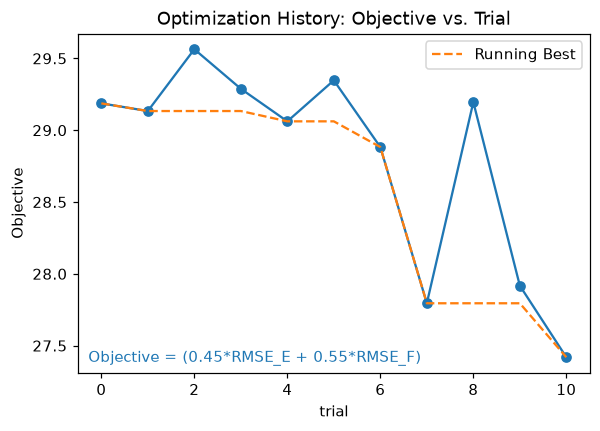

Objective: composite score (meV/atom + meV/Å, weighted)


In [10]:
# optimization history
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["number"], df["value"], "o-")
running_best = df.sort_values("number")["value"].cummin()
ax.plot(df.sort_values("number")["number"], running_best, "--", label="Running Best")
ax.set_xlabel("trial")
ax.set_ylabel("Objective")
ax.set_title("Optimization History: Objective vs. Trial")
ax.text(0.02, 0.02, 
        "Objective = (0.45*RMSE_E + 0.55*RMSE_F)", 
        transform=ax.transAxes, ha="left", va="bottom",
        color="tab:blue")
ax.legend()
plt.show()

print("Objective: composite score (meV/atom + meV/Å, weighted)")

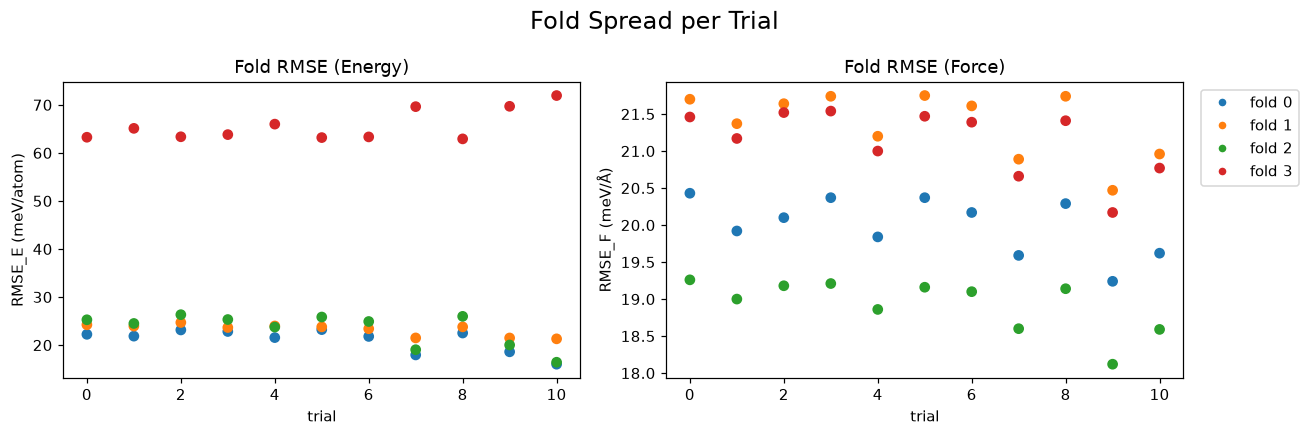

In [11]:
# fold spread per trial (outlier check)
n_folds = len(df["fold_rmse_e"].iloc[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for metric_idx, (metric_name, ax) in enumerate(zip(["fold_rmse_e", "fold_rmse_f"], axes)):
    for _, row in df.sort_values("number").iterrows():
        vals = row[metric_name]
        xs = [row["number"]] * n_folds
        ax.scatter(xs, vals, c=range(n_folds), cmap="tab10", vmin=0, vmax=9)
    ax.set_xlabel("trial")
    y_name = "RMSE_E (meV/atom)" if metric_name == "fold_rmse_e" else "RMSE_F (meV/Å)"
    ax.set_ylabel(y_name)
    title_name = "Fold RMSE (Energy)" if metric_name == "fold_rmse_e" else "Fold RMSE (Force)"
    ax.set_title(title_name)

# legend for fold colors
handles = [plt.Line2D([0], [0], marker="o", color="w",
                        markerfacecolor=plt.cm.tab10(i / 9), label=f"fold {i}")
            for i in range(n_folds)]
axes[1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle("Fold Spread per Trial", fontsize=16)
fig.tight_layout()
plt.show()

In [12]:
importances = optuna.importance.get_param_importances(study)
for param, imp in importances.items():
    print(f"{param:20s} {imp:.3f}")

swa_lr               0.711
swa_energy_weight    0.147
swa_forces_weight    0.081
lr                   0.058
weight_decay         0.004


# Final Training Run
#### Use hyperparameters from the lowest-error Optuna trial in the study and train on the entire test set (all 4 folds).

In [13]:
best_row = df.loc[df["value"].idxmin()]
rmse_f = best_row["fold_rmse_f"]
rmse_e = best_row["fold_rmse_e"]

print(f"""best trial: #{int(best_row['number'])}
params: {study.best_params}

fold RMSE_F (meV/A):      {rmse_f}      mean RMSE_F: {np.mean(rmse_f):.3f}
fold RMSE_E (meV/atom):   {rmse_e}      mean RMSE_E: {np.mean(rmse_e):.3f}

final optimized value (0.45*RMSE_E + 0.55*RMSE_F): {best_row['value']:.4f}""")

best trial: #10
params: {'lr': 0.00047031542728235995, 'weight_decay': 4.785872129643814e-08, 'swa_lr': 9.549912967601715e-05, 'swa_energy_weight': 9.490266915712997, 'swa_forces_weight': 60.146577956482155}

fold RMSE_F (meV/A):      [19.62, 20.96, 18.59, 20.77]      mean RMSE_F: 19.985
fold RMSE_E (meV/atom):   [16.02, 21.3, 16.43, 71.94]      mean RMSE_E: 31.422

final optimized value (0.45*RMSE_E + 0.55*RMSE_F): 27.4194


After `scp`-ing `full_train.sh` over to your LONI directory, copy and paste the `sbatch` command printed below to run.

In [14]:
params = study.best_params

sbatch_cmd = (
    f"sbatch full_train.sh "
    f"{params['lr']} "
    f"{params['weight_decay']} "
    f"{params['swa_lr']} "
    f"{params['swa_energy_weight']} "
    f"{params['swa_forces_weight']}"
)

print(sbatch_cmd)

sbatch full_train.sh 0.00047031542728235995 4.785872129643814e-08 9.549912967601715e-05 9.490266915712997 60.146577956482155
